### Breast Cancer Disease Detection (Beginner–Intermediate ML Project)

This notebook builds and evaluates machine learning models to classify tumors as **benign vs malignant** using the Wisconsin Breast Cancer dataset.

**Dataset Information:**
This project uses the Wisconsin Breast Cancer Diagnostic Dataset sourced from Kaggle.

The dataset contains structured diagnostic measurements derived from digitized images of breast mass cell nuclei and is commonly used for binary classification in cancer detection research.


**Goal:** In healthcare screening, missing a malignant case is costly, so model evaluation prioritizes **Recall (Sensitivity)** while also reporting ROC–AUC, Precision, F1, and Accuracy.

**Workflow:**
1) Load and prepare data  
2) Train Logistic Regression, Random Forest, and XGBoost  
3) Compare models (Recall-first)  
4) Select a final model and analyze errors + threshold behavior (confusion matrix, ROC, PR curves)


In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

sns.set()
plt.style.use('ggplot')

### Install notes
Run this cell only if you see ModuleNotFoundError.
If needed, uncomment and run:
!pip install missingno xgboost


In [66]:
df = pd.read_csv("../data/breast_cancer.csv")



In [67]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Remove Identifier Column (id)

The `id` column is only a unique identifier and does not contain clinical information.
Keeping it can create confusing EDA plots and does not help prediction, so I drop it immediately after loading the dataset.

In [68]:
df = df.drop(columns=["id"], errors="ignore")

### Check  to confirm removal

In [69]:
"id" in df.columns


False

### Dataset Overview

Before doing anything with machine learning, I first want to see what my dataset looks like.
This helps me know what kind of data I have, how many columns there are, what their types are, and if there are any missing values.

In [70]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

### Observation

Rows: 569, Columns: 32.

Most columns are numeric.

diagnosis is text (M/B), so I’ll convert it later.

No obvious missing values here (I’ll double-check next).

###  Descriptive Statistics
Next, we'll examine the descriptive statistics of numeric features using `df.describe()`.  
This gives insights into the range, mean, standard deviation, and distribution of numeric values for each feature.


In [71]:
df.describe()


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### Observation:
- We can see the **mean**, **min**, and **max** values for each feature.  
- Features like `radius_mean`, `texture_mean`, and `area_mean` show different scales — scaling might be needed later for some algorithms.  
- No unexpected extreme outliers are visible from this summary.


###  Missing Value Analysis
Before moving forward, we must check whether our dataset contains any missing or null values.  
We'll first check numerically and then visualize missing data to ensure our dataset is clean.


In [72]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

<Axes: >

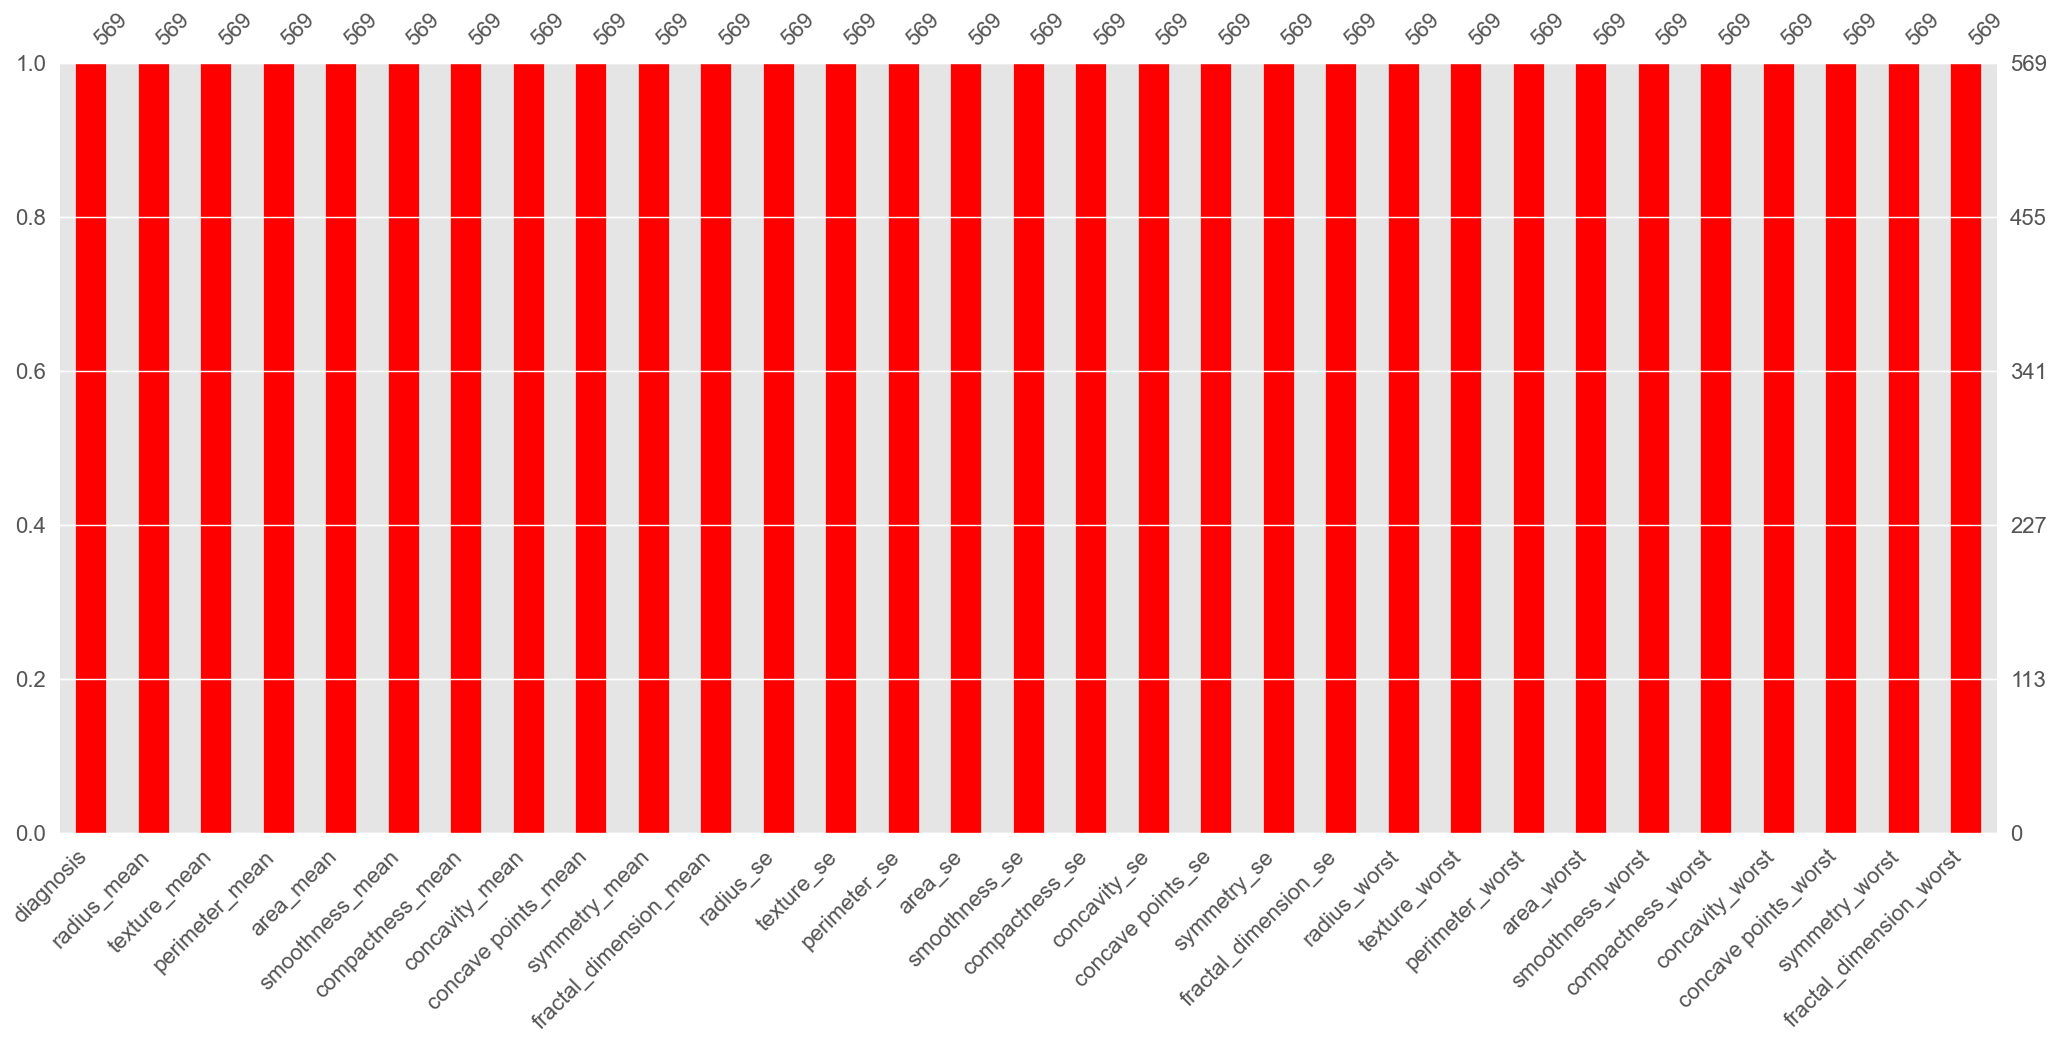

In [73]:
msno.bar(df, color="red")


###  Observation:
- The dataset does not contain any missing values, which means no imputation or cleaning is needed.  
- If there were missing values, we would consider handling them using mean/median (for numeric) or mode (for categorical) imputation.


###  Encode Target Column
The target column `diagnosis` currently contains categorical values 'M' (Malignant) and 'B' (Benign).  
We’ll convert them into numeric values:  
- **M → 1 (Malignant)**  
- **B → 0 (Benign)**  
This step prepares our target variable for machine learning algorithms.


In [74]:
target_col = "diagnosis"
df[target_col] = df[target_col].map({'M': 1, 'B': 0})
df[target_col].value_counts()


diagnosis
0    357
1    212
Name: count, dtype: int64

###  Visualize the Target Variable (Diagnosis)

The `diagnosis` column indicates whether the tumor is **Malignant (M)** or **Benign (B)**.  
Visualizing its distribution helps us understand how balanced the dataset is — whether there are more malignant or benign cases.


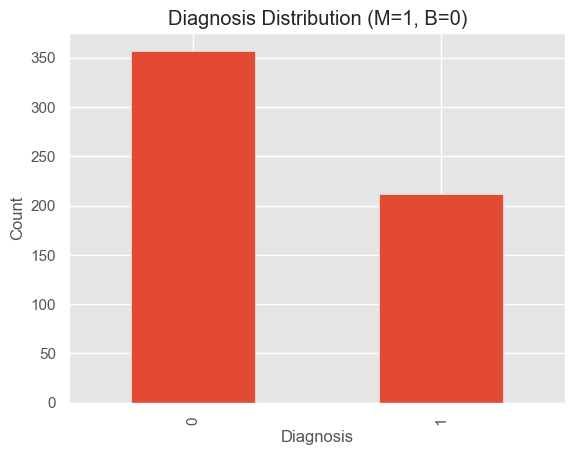

In [75]:
df['diagnosis'].value_counts().plot(kind='bar')
plt.title("Diagnosis Distribution (M=1, B=0)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


###   Exploratory Data Analysis (EDA)

Now that the data cleaning and preprocessing steps are done,  
I will begin exploring the dataset to understand patterns, relationships, and and relationships between features..  
This step includes:
- 5.1 Univariate Analysis  
- 5.2 Bivariate / Multivariate Analysis  
- 5.3 Correlation Heatmap


###   Univariate Analysis

Here I check how each numeric column is spread out.  
This helps me see if the values are balanced, skewed, or have outliers.


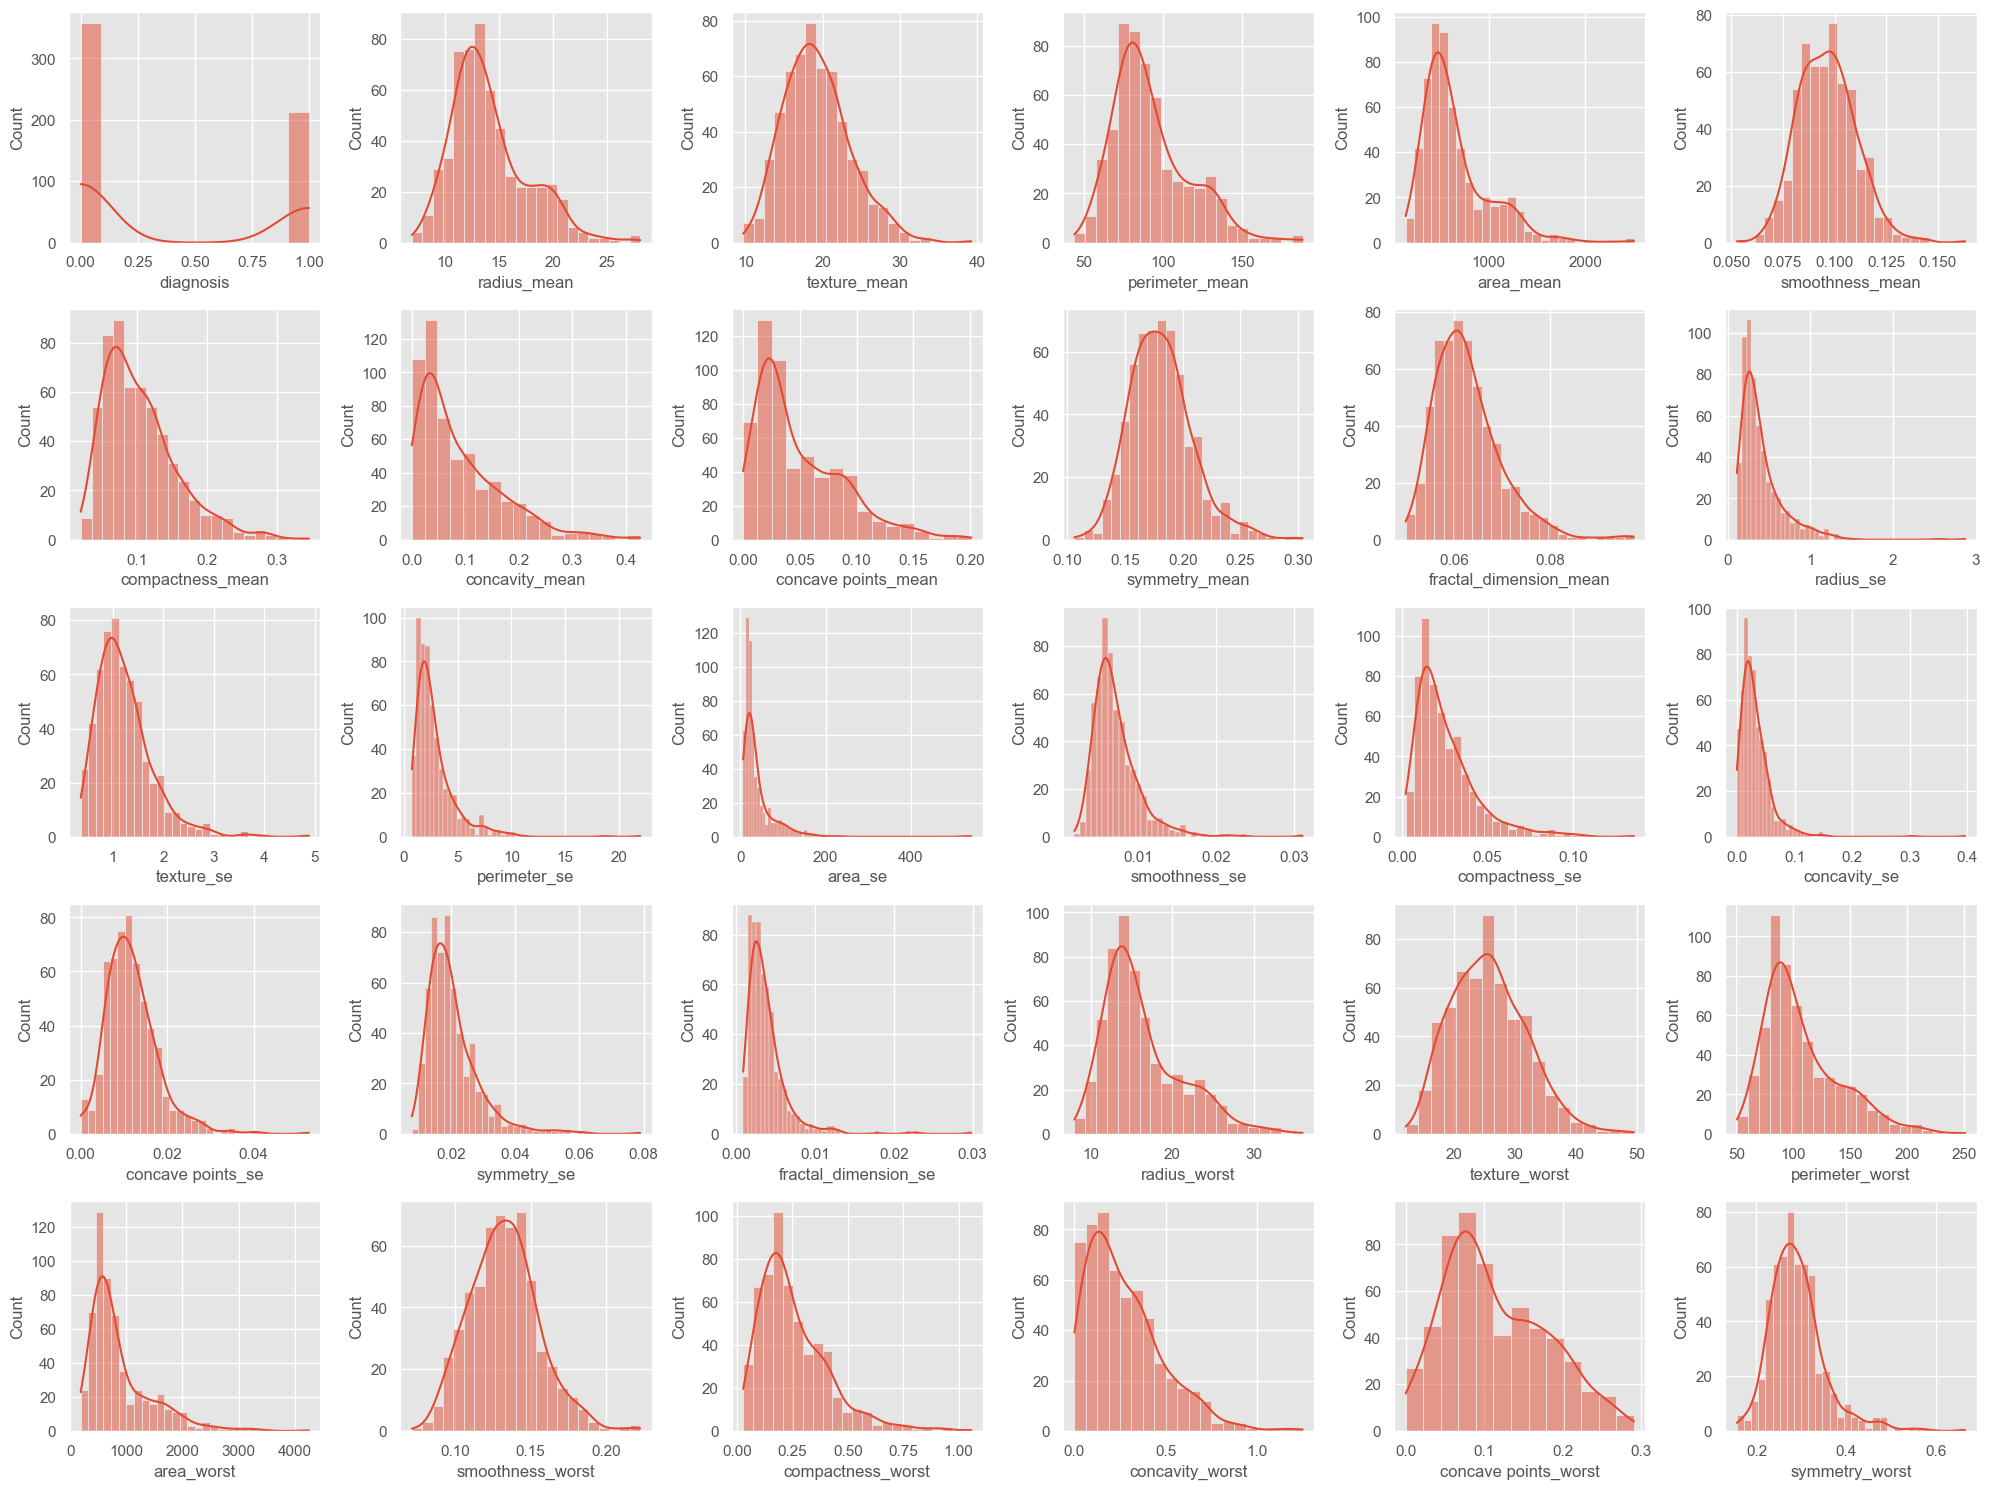

In [76]:
# Plot feature distributions to understand scale and skew.

plt.figure(figsize=(20,15))
plotnumber=1
for column in df:
    if plotnumber<=30:
        ax = plt.subplot(5,6, plotnumber)
        sns.histplot(df[column], kde=True)
    
        plt.xlabel(column)
    plotnumber+=1

plt.tight_layout()
plt.show()

### Bivariate Analysis (Box Plots)

Before jumping into modeling, I wanted to quickly check how some important numeric features behave for the two classes in the dataset (benign = 0, malignant = 1). 
Instead of plotting all the features, I picked two that usually show a clear difference between the classes: **radius_mean** and **area_mean**.

These plots help me see if the values are generally higher or lower for malignant tumors compared to benign ones.


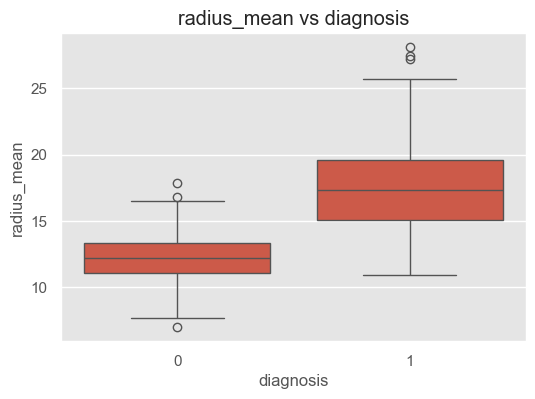

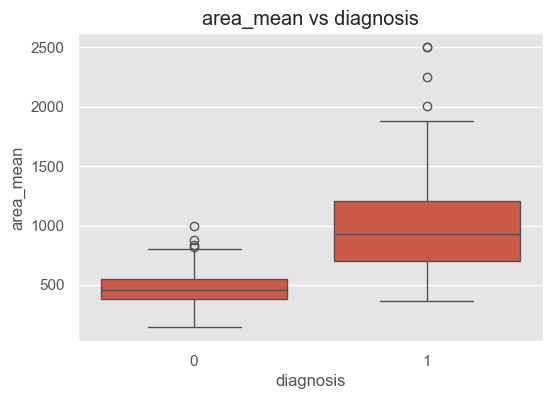

In [77]:
target_col = "diagnosis"

# BEST feature 1
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x=target_col, y="radius_mean")
plt.title("radius_mean vs diagnosis")
plt.show()

# BEST feature 2
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x=target_col, y="area_mean")
plt.title("area_mean vs diagnosis")
plt.show()


### Observations

- For **radius_mean**, I noticed that the malignant class (1) generally has higher radius values compared to the benign class (0). The boxplot shows a clear upward shift in the median.

- For **area_mean**, the malignant tumors also show larger area values. The difference between the two classes is quite visible here too.

Overall, these two features already give a hint that tumor size-related measurements may help the model learn the difference between the two classes.


## Prepare Features (X) and Target (y)

Now we separate the dataset into:
- **X (features):** all input columns used for prediction
- **y (target):** the column we want to predict (`diagnosis`)

Important: We **exclude the target column from X** so that correlation analysis and feature selection are done only on input features (this avoids leakage and keeps analysis correct).

In [78]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]


### Correlation Heatmap

Finally, I check how strongly numeric features are related to one another.  
This helps find pairs that share similar information.


In [79]:
corr = X.corr()


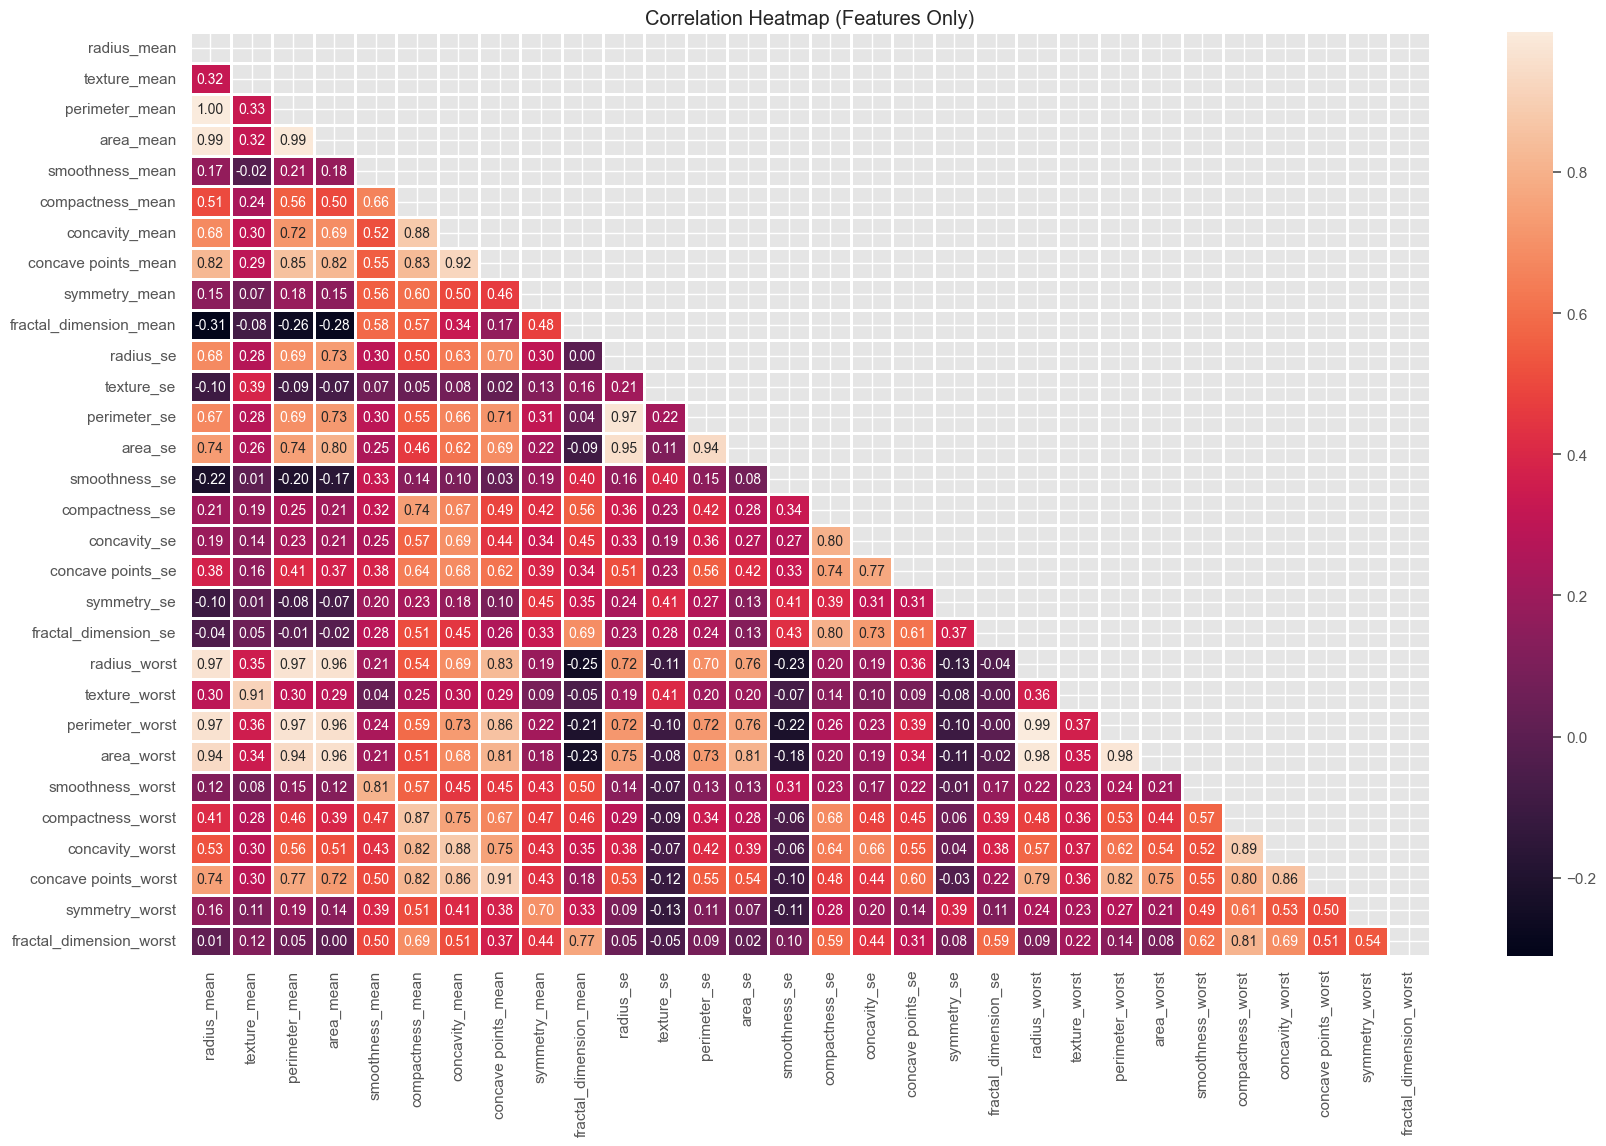

In [80]:
# heatmap (features only)
plt.figure(figsize=(20,12))
corr = X.corr()   # ✅ change from df.corr() to X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, linewidths=1, annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Features Only)")
plt.show()


### Observation:
Some feature pairs show strong correlation, indicating they capture similar information.
To avoid redundancy, correlated features can be removed or retained depending on the model.
For this project, we will keep all features for now and allow the models to determine
which features are most useful.


### Feature Selection (Dropping Highly Correlated Features)

Some features in the dataset were extremely similar to each other based on the correlation values. 
To avoid repeating the same information in the model, I dropped the features that had a correlation 
higher than 0.92 with another feature.


In [81]:
corr_threshold = 0.92

corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if (upper[col] > corr_threshold).any()]
print("Highly correlated columns to drop:", to_drop)

X = X.drop(columns=to_drop)
print("X shape after dropping correlated columns:", X.shape)

Highly correlated columns to drop: ['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst']
X shape after dropping correlated columns: (569, 22)


### Observations

- A few features were strongly correlated and did not add new information.
- I dropped those columns to keep the dataset clean and reduce duplicate patterns.
- This helps the model train better and reduces multicollinearity.


In [82]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Feature Reduction Summary

To reduce redundancy, highly correlated features were removed, reducing the feature count 32 feature reduce it 23 now 
This helps keep the model simpler while preserving predictive signal.

## Model Training and Evaluation
Now that preprocessing and feature selection are done, I will split the data, scale the features, train three models, and check their performance.


### **Observation:**  
The shapes confirm that X contains all selected features and y contains the diagnosis labels.  



###  Train–test split
I split the data into training and test sets to evaluate the model on unseen data.


In [83]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train ,y_test =train_test_split(X,y, test_size=0.2, random_state=42,stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((455, 22), (114, 22), (455,), (114,))

**Observation:** 80% data is for training and 20% for testing.


### Feature scaling # scaling data (StandardScaler)
The numeric features have different ranges,  I use StandardScaler so all features have a similar scale.

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [85]:
X_train.shape

(455, 22)

### Logistic Regression – Model Training

I use Logistic Regression as a simple baseline model on the scaled features.

In [86]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Logistic Regression – Evaluation

I check accuracy, precision, recall and F1-score on the test set.

In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_lr = lr_model.predict(X_test_scaled)

lr_accuracy  = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall    = recall_score(y_test, y_pred_lr)
lr_f1        = f1_score(y_test, y_pred_lr)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1-score :", lr_f1)

Accuracy : 0.9649122807017544
Precision: 1.0
Recall   : 0.9047619047619048
F1-score : 0.95


**Observation:**  
Logistic Regression provides a simple baseline and helps me compare the tree-based models.

**Note:** Logistic Regression benefits from scaling. Tree-based models (Random Forest, XGBoost) do not require scaling, so I use raw features for those models.

### Random Forest – Model Training

Random Forest combines many decision trees and is often strong on tabular medical data.

In [88]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Random Forest – Evaluation

I use the same metrics to compare Random Forest with Logistic Regression.

In [89]:
y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-score :", rf_f1)


Accuracy : 0.9649122807017544
Precision: 0.975
Recall   : 0.9285714285714286
F1-score : 0.9512195121951219


### **Observation:**  
With limited tree depth and at least two samples per leaf, the Random Forest model performs well without clearly overfitting.

### XGBoost – Model Training and Evaluation

XGBoost builds many small trees one after another, and each new tree focuses on correcting some of the previous errors.

In [90]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [91]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_xgb = xgb_model.predict(X_test)

xgb_accuracy  = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall    = recall_score(y_test, y_pred_xgb)
xgb_f1        = f1_score(y_test, y_pred_xgb)

print("XGB Accuracy :", xgb_accuracy)
print("XGB Precision:", xgb_precision)
print("XGB Recall   :", xgb_recall)
print("XGB F1-score :", xgb_f1)

XGB Accuracy : 0.9385964912280702
XGB Precision: 0.9487179487179487
XGB Recall   : 0.8809523809523809
XGB F1-score : 0.9135802469135802


### **Observation:** XGBoost handles complex patterns and often performs very well.


### **Compare All Models**

### Evaluation focus (healthcare-friendly)

In cancer detection, missing a malignant case (false negative) is more costly than predicting extra false positives.
So I prioritize Recall (Sensitivity) while still reporting ROC–AUC, Precision, F1, and Accuracy.




### Computing probabilities for ROC–AUC

To compare models fairly, I compute **ROC–AUC** using predicted probabilities
. These probabilities are also used later
for ROC and Precision–Recall curves.


In [92]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve 
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_auc_score



# Probabilities (needed for ROC-AUC)
y_prob_lr  = lr_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

auc_lr  = roc_auc_score(y_test, y_prob_lr)
auc_rf  = roc_auc_score(y_test, y_prob_rf)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)


In [93]:
print("ROC–AUC scores:")
print("Logistic Regression:", auc_lr)
print("Random Forest:", auc_rf)
print("XGBoost:", auc_xgb)


ROC–AUC scores:
Logistic Regression: 0.9957010582010581
Random Forest: 0.9933862433862434
XGBoost: 0.9897486772486772


### Decision Threshold Consideration

Model predictions are generated using the default probability threshold (0.50).  
In clinical screening contexts, this threshold can be adjusted to increase Recall (Sensitivity), reducing the likelihood of missed malignant cases at the cost of additional false positives.


### Model Performance Table¶
In cancer detection, missing a malignant case (false negative) is more costly than predicting extra false positives. So I prioritize Recall (Sensitivity) while still reporting ROC–AUC, Precision, F1, and Accuracy.
I collect the main test metrics for the three models in one table.

In [94]:


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Recall":    [lr_recall, rf_recall, xgb_recall],
    "ROC-AUC":   [auc_lr,    auc_rf,    auc_xgb],
    "Precision": [lr_precision, rf_precision, xgb_precision],
    "F1":        [lr_f1,     rf_f1,     xgb_f1],
    "Accuracy":  [lr_accuracy, rf_accuracy, xgb_accuracy],
})

results_df = results_df.sort_values(by=["Recall", "ROC-AUC"], ascending=False).reset_index(drop=True)
results_df



,Model,Recall,ROC-AUC,Precision,F1,Accuracy
0,Random Forest,0.928571,0.993386,0.975000,0.95122,0.964912
1,Logistic Regression,0.904762,0.995701,1.000000,0.95000,0.964912
2,XGBoost,0.880952,0.989749,0.948718,0.91358,0.938596


**Observation:**  
The table shows that **Random Forest achieves the highest Recall**, which is the most important metric for this clinical screening use case because it reduces the chance of missing malignant cases (false negatives). ROC-AUC is also strong across models, indicating good overall class separation.


### Model comparison (Recall priority)

Recall is the main metric because the goal is to avoid missing malignant cases.
I also include ROC–AUC to compare how well each model separates the two classes across different thresholds.


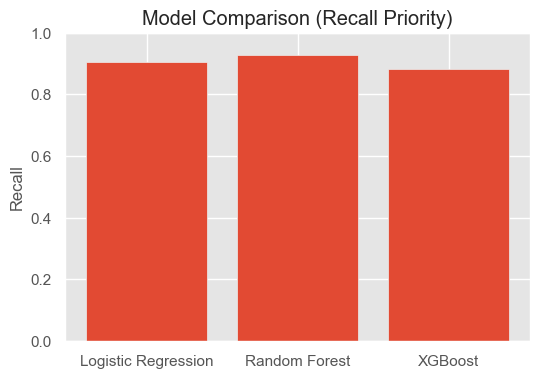

In [95]:


models = ["Logistic Regression", "Random Forest", "XGBoost"]
recall_scores = [lr_recall, rf_recall, xgb_recall]

plt.figure(figsize=(6, 4))
plt.bar(models, recall_scores)
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.title("Model Comparison (Recall Priority)")
plt.show()


### Model Comparison Summary

| Model | Recall | ROC-AUC | Selected |
|------|--------|---------|----------|
| Logistic Regression | 0.90 | 0.99 | ❌ |
| Random Forest | 0.93 | 0.99 | ✅ Final Model |
| XGBoost | 0.88 | 0.98 | ❌ |


## Final Model Selection

Based on comparative evaluation across multiple metrics, Random Forest was selected as the final predictive model.

The selection was guided primarily by Recall performance, given the clinical importance of minimizing missed malignant cases.

Further evaluation was conducted using:

- Confusion Matrix
- ROC Curve
- Precision–Recall Curve

These analyses confirmed strong diagnostic sensitivity and probability separation.


## Feature Importance (Random Forest)

Since Random Forest is the final model, I visualize the most important features.
This gives a simple interpretability view of which measurements the model relied on most.

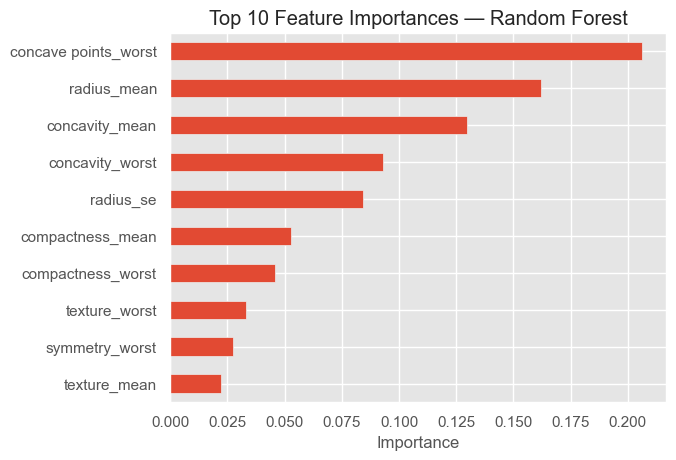

In [96]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top10 = importances.sort_values().tail(10)

top10.plot(kind="barh")
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.show()

### **Observation:** This plot shows the top features used by the Random Forest model.
This is not a causal explanation, but it helps interpret model behavior.

## Cross-Validation (Recall)

To avoid relying only on one 80/20 split, I run 5-fold cross-validation and report average Recall.
This checks whether performance is stable across different splits.

In [97]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_cv = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42
)

cv_scores = cross_val_score(rf_cv, X, y, cv=5, scoring="recall")
print(f"CV Recall: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV Recall: 0.924 ± 0.010


### **Observation:** Cross-validation gives a more reliable estimate than a single split.
Mean Recall shows typical performance, and the ± value shows variability across folds.

### Confusion matrix visualization

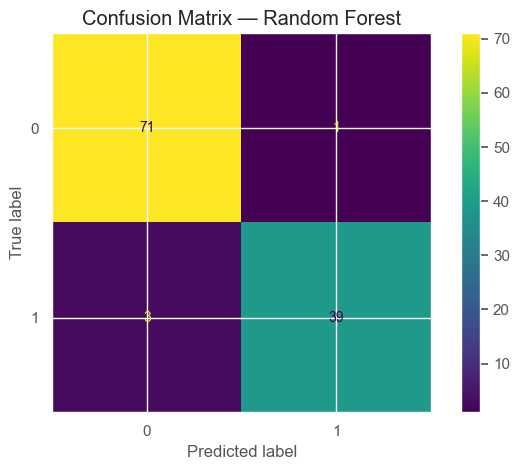

In [98]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, values_format='d')
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()


**Confusion Matrix – Interpretation:**  
The key value to monitor here is the number of **false negatives (malignant predicted as benign)**. Since the objective is high sensitivity, the model’s performance is considered strong when false negatives are minimized.


### ROC curve (final model only)

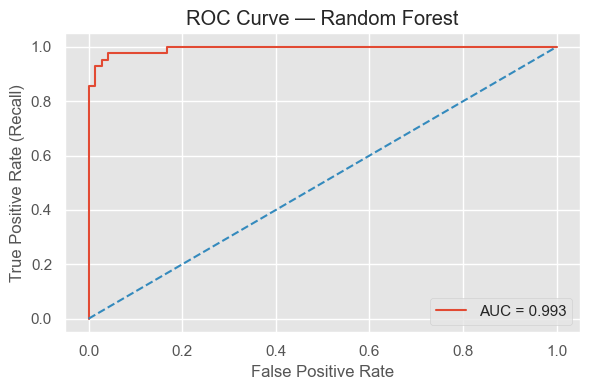

In [99]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()


**ROC Curve – Interpretation:**  
The curve staying close to the top-left corner and a high ROC-AUC indicate strong overall discrimination between malignant and benign cases across different thresholds.


### Precision–Recall curve (final model only)

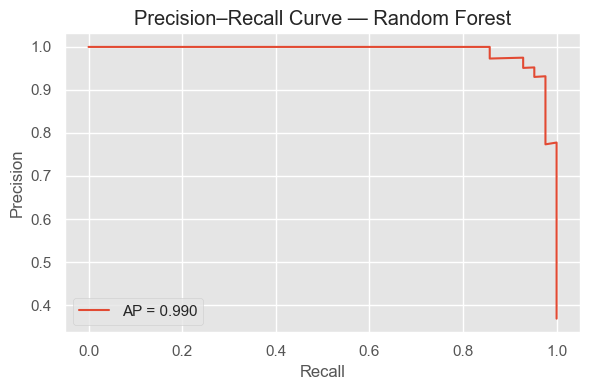

In [100]:
# Use Random Forest probabilities for PR curve (final model)
precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)
ap = average_precision_score(y_test, y_prob_rf)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

**Precision–Recall Curve – Interpretation:**  
The PR curve highlights the trade-off between catching more malignant cases (higher Recall) and introducing more false positives (lower Precision). This view is especially useful when prioritizing Recall in a medical screening workflow.


### Evaluation Summary (Test Set)

The selected Random Forest model was evaluated on the test set using:
- Confusion Matrix
- ROC Curve
- Precision–Recall Curve

These metrics help assess sensitivity (recall) and trade-offs relevant to cancer screening.

In [101]:
final_model_name = "Random Forest"
final_model = rf_model


## Model Packaging for Inference 

After selecting and evaluating the Random Forest model, I package the final model for inference.
This means I train the final model on the full dataset and save it as a file, so it can be loaded later
to make predictions on new input data (without retraining).

In [104]:
import os
import joblib
from sklearn.ensemble import RandomForestClassifier

# Train final model on full dataset (X, y)
final_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42
)
final_model.fit(X, y)

# Save model file
os.makedirs("artifacts", exist_ok=True)
joblib.dump(final_model, "artifacts/model.joblib")
print("✅ Saved model: artifacts/model.joblib")

# Create small sample input file (5 rows) for demo inference
X.head(5).to_csv("sample_input.csv", index=False)
print("✅ Created: sample_input.csv")

✅ Saved model: artifacts/model.joblib
✅ Created: sample_input.csv


## Conclusion

The final Random Forest model achieved strong discrimination and high sensitivity on the test set,
which is especially important in cancer detection to reduce missed malignant cases.

In addition to model evaluation, the final model was packaged for inference by:

- Training on the full cleaned dataset
- Saving the model as `model.joblib`
- Creating a sample input file for demonstration

This completes an end-to-end workflow from data preprocessing and model selection
to basic model packaging for inference.

### Future Scope

This project currently demonstrates:

- End-to-end predictive modeling
- Model comparison and recall prioritization
- Basic interpretability (feature importance)
- Cross-validation for reliability
- Simple model packaging for inference

Possible future enhancements include:

- Building a Streamlit-based interactive prediction app
- Adding threshold tuning for clinical sensitivity targets
- Integrating the model into a simple API
- Deploying to a cloud platform
- Exploring more advanced interpretability methods (e.g., SHAP)